In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.cm import get_cmap

from scipy import stats
from scipy.ndimage import gaussian_filter, gaussian_filter1d

import sys
sys.path.append("..//neural/")
import format_waveform_data, waveform_analysis
sys.path.append("..//utils/")
from load_matlab_data import loadmat_sbx
from format_behavior_data import load_behavior_data, get_feeder_ints, get_feeder_periods, classify_feeder_ints

import scipy.io
import os
from scipy.io import loadmat, savemat

In [3]:
''' File Paths '''
root_dir = "Z:/Isabel/data/hpc_implants/"
save_figs_dir = f"../figures/basic_neural_analysis/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"
posture_file = 'posture_pos_smooth.npy'

In [392]:
def get_foot_angle(data_dir, posture_file):
    # get a vector between the two feet
    smooth_posture_preds = np.load(f'{data_dir}{posture_file}') # time x keypoints x xyz
    feet_xy = smooth_posture_preds[:, [10, 14], :2]
    feet_vector = feet_xy[:, 0] - feet_xy[:, 1]

    # compute the angle between adjacent feet vectors
    v1 = feet_vector[:-1]
    v2 = feet_vector[1:]
    mag_v1 = np.sqrt(v1[:, 0]**2 + v1[:, 1]**2)
    mag_v2 = np.sqrt(v2[:, 0]**2 + v2[:, 1]**2)
    dot = np.sum(v1*v2, axis=1)
    
    # regularize
    mag_v1[mag_v1 < 0.01] = 0.01
    mag_v2[mag_v2 < 0.01] = 0.01
    
    cos_theta = dot / (mag_v1*mag_v2)
    cos_theta[cos_theta < -1] = -1
    cos_theta[cos_theta > 1] = 1

    # compute the angle
    feet_angle = np.arccos(cos_theta)
    feet_angle = np.append(feet_angle, 0)
    
    return feet_angle

In [393]:
'''
Detect feeder done state
- end bound = feet leave feeder perch
- start bound = last beak on feeder

--> if eat b/w start and end bounds, done eating = start
--> if turns around between start and end bounds, turn = end 
'''
def get_feeder_departure_bounds(count_data, feeder_perches=np.asarray([84, 85, 86, 87])):
    ''' get feeder visits '''
    # all perches
    all_perch_start = count_data['newPerch']
    all_perch_end = count_data['endPerch']
    all_perch_idx = count_data['perchNum']
    n_perches = all_perch_end.shape[0]
    
    # feeder departures
    feeder_depart_start = []
    feeder_depart_end = []
    feeder_idx = []
    for i, (ps, pe) in enumerate(zip(all_perch_start, all_perch_end)):
        this_perch = all_perch_idx[i]
        if this_perch in feeder_perches:
            feeder_depart_start.append(ps)
            feeder_depart_end.append(pe)
            feeder_idx.append(np.where(feeder_perches==this_perch)[0][0] + 1)
    feeder_depart_start = np.asarray(feeder_depart_start)
    feeder_depart_end = np.asarray(feeder_depart_end)
    feeder_idx = np.asarray(feeder_idx)
    
    ''' refine by beak on feeder (if relevant) '''
    # last time the beak was near the feeder
    end_beak_on_feeder = count_data['endFeeder']
    for i, (fs, fe) in enumerate(zip(feeder_depart_start, feeder_depart_end)):
        after_start = end_beak_on_feeder > fs
        before_end = end_beak_on_feeder < fe
        if any(after_start & before_end):
            this_beak_end = np.argmax(np.cumsum(after_start & before_end))
            feeder_depart_start[i] = end_beak_on_feeder[this_beak_end]
    
    ''' refine to exclude eating '''
    eat_offsets = count_data['endBeakPerch']
    for i, (fs, fe) in enumerate(zip(feeder_depart_start, feeder_depart_end)):
        after_start = eat_offsets > fs
        before_end = eat_offsets < fe
        if any(after_start & before_end):
            this_offset = np.argmax(np.cumsum(after_start & before_end))
            feeder_depart_start[i] = eat_offsets[this_offset]
    assert np.sum((feeder_depart_end - feeder_depart_start) < 0) == 0

    return feeder_depart_start, feeder_depart_end, feeder_idx

In [358]:
bird = 'RBY94'
session_id = '241129'

In [359]:
data_dir = f"{root_dir}{bird}/{bird}_{session_id}/behavior_data/"

In [360]:
feet_angle = get_foot_angle(data_dir, posture_file)
feeder_depart_start, feeder_depart_end, feeder_idx = get_feeder_departure_bounds(count_data)
n_feeder_int = feeder_depart_start.shape[0]

C:\Users\Isabel\AppData\Local\Temp\ipykernel_132908\3156943063.py:13: RuntimeWarning: invalid value encountered in arccos
  feet_angle = np.arccos(dot / (mag_v1*mag_v2))


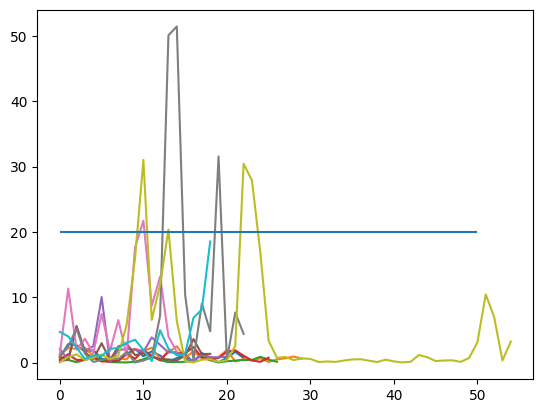

In [361]:
for i in range(10):
    plt.plot(np.degrees(feet_angle[feeder_depart_start[i]:feeder_depart_end[i]]))
plt.hlines(20, 0, 50)

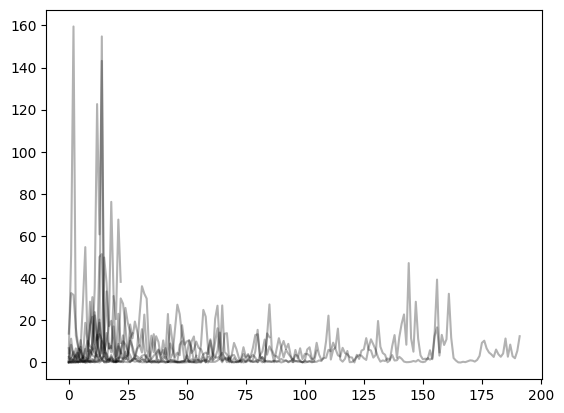

In [362]:
''' find the time when the foot angle changes - bird leaves feeder'''
angle_thresh = 20 # degrees
feeder_end = np.zeros(n_feeder_int)

no_leave = 0
max_subthresh = []
leave_angles = []

for f_idx, (start_t, end_t) in enumerate(zip(feeder_depart_start, feeder_depart_end)):
    these_angles = np.degrees(feet_angle[start_t:end_t])
    leave_idx = np.argmax(these_angles >= angle_thresh)
    if np.sum(these_angles >= angle_thresh):
        feeder_end[f_idx] = np.min([leave_idx, end_t])
        plt.plot(these_angles, 'k', alpha=0.3, zorder=1)
        # plt.vlines(np.min([leave_idx, end_t]), 0, 180, colors='red', linestyles='dotted', lw=0.8, zorder=0)
        leave_angles.append(np.max(these_angles))
    else:
        feeder_end[f_idx] = end_t
        max_subthresh.append(np.max(these_angles))
        leave_angles.append(np.max(these_angles))

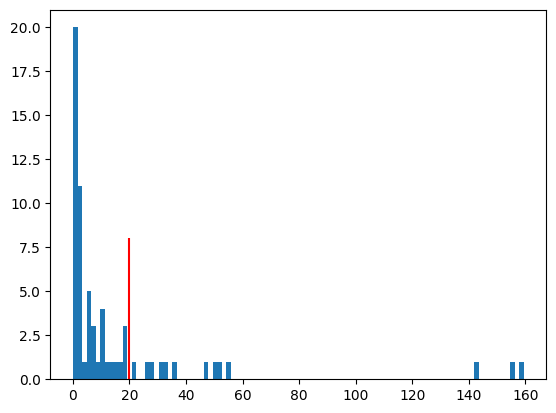

In [363]:
plt.hist(leave_angles, bins=100)
plt.vlines(20, 0, 8, colors='red')
plt.show()

In [364]:
smooth_posture_preds = np.load(f'{data_dir}{posture_file}') # time x keypoints x xyz
feet_xy = smooth_posture_preds[:, [10, 14], :2]
feet_vector = feet_xy[:, 0] - feet_xy[:, 1]

In [379]:
v1 = feet_vector[:-1]
v2 = feet_vector[1:]
mag_v1 = np.sqrt(v1[:, 0]**2 + v1[:, 1]**2)
mag_v2 = np.sqrt(v2[:, 0]**2 + v2[:, 1]**2)

In [382]:
dot = np.sum(v1*v2, axis=1)

In [380]:
mag_v1[mag_v1<0.01] = 0.01
mag_v2[mag_v2<0.01] = 0.01

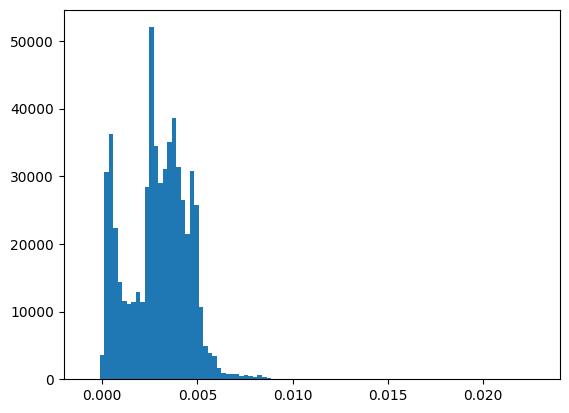

In [383]:
plt.hist(dot, bins=100)
plt.show()

In [398]:
align_to_feet = True
feeder_int_start, feeder_int_end, feeder_idx = get_feeder_ints(count_data, use_beak=False)
if align_to_feet:
    feet_angle = get_foot_angle(data_dir, posture_file)
    feeder_depart_start, feeder_depart_end, feeder_idx = get_feeder_departure_bounds(count_data)
    assert feeder_int_end.shape[0] == feeder_depart_end.shape[0]
    for f_idx, (start_t, end_t) in enumerate(zip(feeder_depart_start, feeder_depart_end)):
        these_angles = np.degrees(feet_angle[start_t:end_t])
        leave_idx = np.argmax(these_angles >= angle_thresh)
        if np.sum(these_angles >= angle_thresh):
            feeder_int_end[f_idx] = np.min([start_t+leave_idx, end_t])
feeder_open_times, feeder_close_times = get_feeder_periods(session_info_file, bird, session_id)
feeder_status = classify_feeder_ints(feeder_int_start, feeder_int_end, feeder_open_times, feeder_close_times)
n_feeder_int = feeder_int_start.shape[0]

In [399]:
feeder_int_end

array([ 30363,  35952,  39061,  43260,  45581,  50560,  61208,  61954,
        62707,  64251, 109925, 124984, 131434, 132682, 148942, 163457,
       166077, 168884, 169461, 170702, 171429, 174664, 176227, 178792,
       186474, 191303, 194385, 194961, 197490, 202523, 209644, 211289,
       211741, 212705, 213949, 214537, 215123, 293512, 297179, 305191,
       306126, 323653, 335434, 336630, 341806, 342517, 343408, 347533,
       348078, 351076, 351360, 353037, 354508, 355440, 356242, 357715,
       358432, 362393, 363390, 366262, 372417, 376629, 379694, 383947,
       384993])

In [397]:
feeder_depart_start

array([ 30340,  35922,  39034,  43234,  45560,  50541,  61198,  61941,
        62697,  64232, 109887, 124850, 131221, 132631, 148941, 163299,
       166023, 168674, 169307, 170547, 171378, 174640, 176182, 178693,
       186447, 191282, 194370, 194938, 197468, 202501, 209621, 211267,
       211613, 212682, 213907, 214512, 215098, 293434, 297115, 305130,
       306009, 323584, 335400, 336590, 341780, 342494, 343380, 347510,
       348067, 350991, 351238, 352985, 354477, 355376, 356215, 357692,
       358406, 362382, 363384, 366233, 372361, 376628, 379681, 383855,
       384928])